In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc


In [2]:
df = pd.read_csv("/Users/abhaysinghrana/Desktop/internship project/smart_manufacturing_data.csv")

In [3]:
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [4]:
#Include Anomaly Flag as Input after Anomaly Detection Model ANN
X = df.drop(columns=['timestamp', 'machine_id',	'predicted_remaining_life',	'failure_type',	'downtime_risk','maintenance_required'])
y_maintenance = df['maintenance_required'].values.astype(np.float32)

In [5]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

In [6]:
# Split train data (85%) dan test data (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_maintenance, test_size=0.15, random_state=42)

# Split X_temp to train data (70%) and val data (15%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)  # 0.1765 x 0.85 ≈ 0.15


class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [7]:
#Binary Class model For Predictive Maintenance

class BinaryClassifierANN(nn.Module):
    def __init__(self, input_dim, hidden_size1):
        super(BinaryClassifierANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_size1),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_size1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [8]:
# Evaluate and Training Function
input_dim = X_train.shape[1]
train_losses = []
val_losses = []
test_losses = []

train_accuracies = []
val_accuracies = []
test_accuracies = []

def evaluate_model(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            X_batch, y_batch = batch
            outputs = model(X_batch).squeeze()

            if isinstance(loss_fn, nn.CrossEntropyLoss):
                loss = loss_fn(outputs, y_batch)
                preds = torch.argmax(outputs, dim=1)
            else:
                loss = loss_fn(outputs, y_batch)
                preds = (outputs > 0.5).float()

            total_loss += loss.item()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy



def train_with_eval(model, optimizer, loss_fn, train_loader, val_loader, test_loader, num_epochs):
    train_losses, val_losses, test_losses = [], [], []
    train_accuracies, val_accuracies, test_accuracies = [], [], []

    for epoch in range(num_epochs):
        # ===== TRAINING =====
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:
            X_batch, y_batch = batch 

            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()

            if isinstance(loss_fn, nn.CrossEntropyLoss):
                loss = loss_fn(outputs, y_batch)
                preds = torch.argmax(outputs, dim=1)
            else:
                loss = loss_fn(outputs, y_batch)
                preds = (outputs > 0.5).float()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = correct / total

        # ===== EVALUASI =====
        val_loss, val_accuracy = evaluate_model(model, val_loader, loss_fn)
        test_loss, test_accuracy = evaluate_model(model, test_loader, loss_fn)

        # Simpan semua
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        test_accuracies.append(test_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f}, Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_accuracy:.4f} | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_accuracy:.4f}")

    return train_losses, val_losses, test_losses, train_accuracies, val_accuracies, test_accuracies




In [9]:

model_maintenance = BinaryClassifierANN(input_dim, hidden_size1=4)

bce = nn.BCELoss()

optimizer = torch.optim.Adam(model_maintenance.parameters(), lr=0.0001)

train_losses, val_losses, test_losses, train_accuracies, val_accuracies, test_accuracies = train_with_eval(
    model_maintenance, optimizer, bce,
    train_loader, val_loader, test_loader,
    num_epochs=20
)

Epoch 1/20 | Train Loss: 0.7418, Acc: 0.3391 | Val Loss: 0.6782, Acc: 0.5354 | Test Loss: 0.6779, Acc: 0.5435
Epoch 2/20 | Train Loss: 0.6251, Acc: 0.6184 | Val Loss: 0.5557, Acc: 0.8030 | Test Loss: 0.5538, Acc: 0.8078
Epoch 3/20 | Train Loss: 0.5161, Acc: 0.7555 | Val Loss: 0.4421, Acc: 0.8912 | Test Loss: 0.4395, Acc: 0.8948
Epoch 4/20 | Train Loss: 0.4218, Acc: 0.8521 | Val Loss: 0.3479, Acc: 0.9301 | Test Loss: 0.3452, Acc: 0.9326
Epoch 5/20 | Train Loss: 0.3493, Acc: 0.9076 | Val Loss: 0.2753, Acc: 0.9515 | Test Loss: 0.2726, Acc: 0.9531
Epoch 6/20 | Train Loss: 0.2947, Acc: 0.9174 | Val Loss: 0.2208, Acc: 0.9655 | Test Loss: 0.2182, Acc: 0.9667
Epoch 7/20 | Train Loss: 0.2534, Acc: 0.9215 | Val Loss: 0.1814, Acc: 0.9720 | Test Loss: 0.1788, Acc: 0.9725
Epoch 8/20 | Train Loss: 0.2250, Acc: 0.9225 | Val Loss: 0.1535, Acc: 0.9741 | Test Loss: 0.1510, Acc: 0.9743
Epoch 9/20 | Train Loss: 0.2046, Acc: 0.9213 | Val Loss: 0.1341, Acc: 0.9745 | Test Loss: 0.1316, Acc: 0.9746
Epoch 10/2

In [10]:
#Plot Loss and Scatter Function
def plot_all_curves(train_losses, val_losses, test_losses, train_accuracies, val_accuracies, test_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.plot(epochs, test_losses, label='Test Loss', color='green')
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Acc', color='blue')
    plt.plot(epochs, val_accuracies, label='Val Acc', color='orange')
    plt.plot(epochs, test_accuracies, label='Test Acc', color='green')
    plt.title("Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_scatter(ytes, ypred):
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(ytes)),ytes , label='Actual', color='b')
    plt.scatter(range(len(ypred)),ypred, label='Prediction', color='r')
    plt.legend(loc="center right")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Pred vs Actual")
    plt.show()

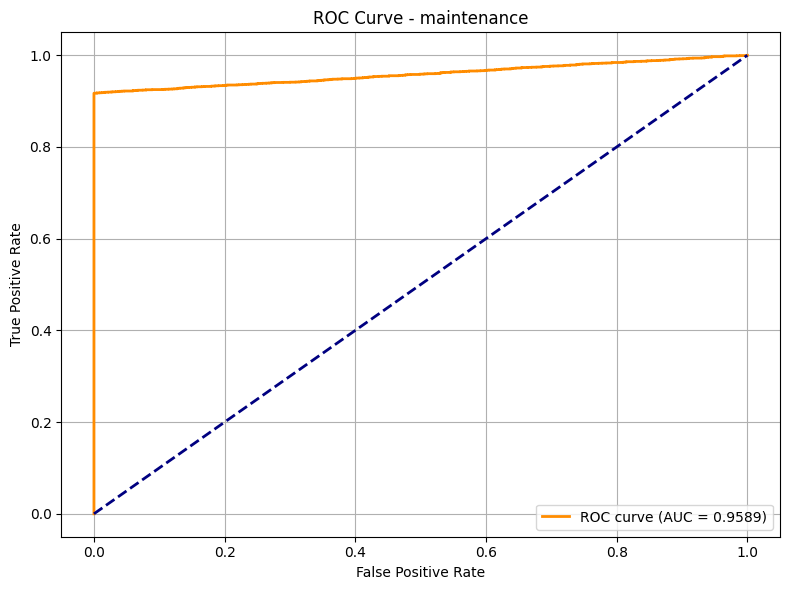

In [11]:
# Plot ROC CURVE
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Probabilitas prediksi (bukan threshold 0.5)
model_maintenance.eval()
with torch.no_grad():
    y_pred = model_maintenance(X_test_tensor).squeeze().numpy()

# ROC Curve dan AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - maintenance')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

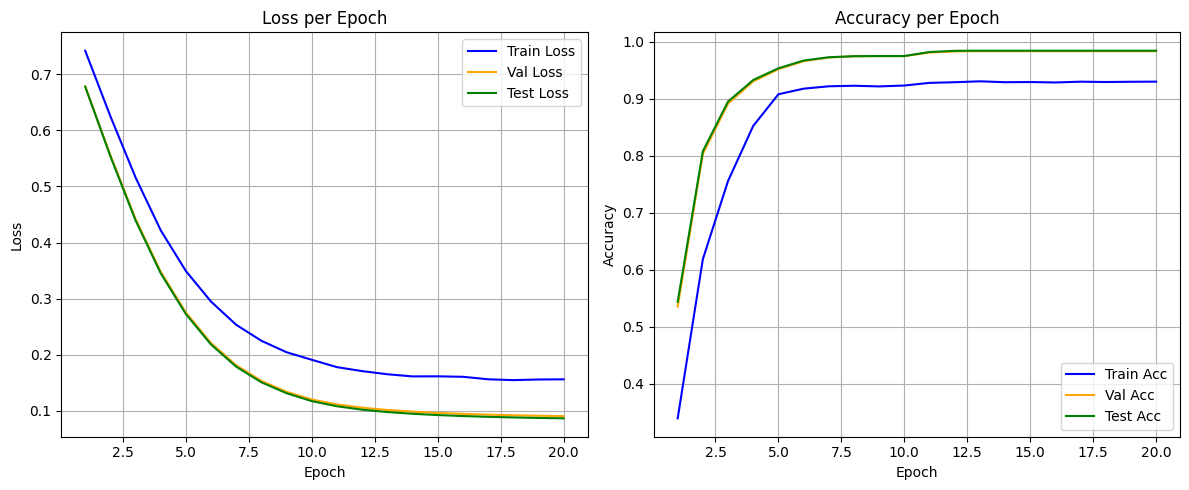

In [12]:
plot_all_curves(train_losses, val_losses, test_losses, train_accuracies, val_accuracies, test_accuracies)


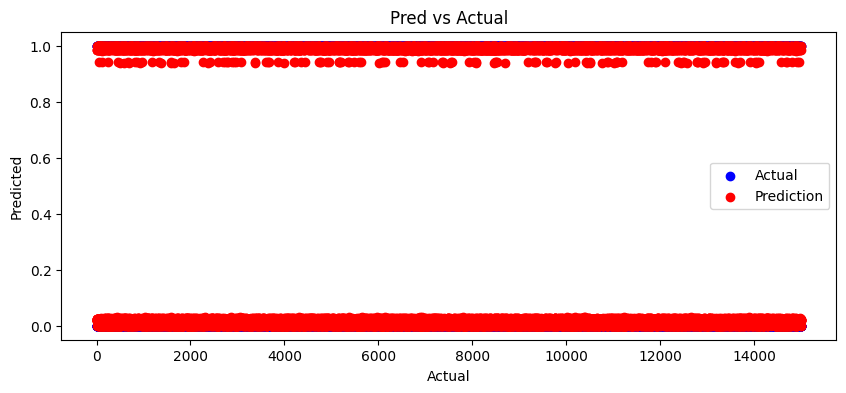

In [13]:
plot_scatter(y_test, y_pred)

In [14]:
#Use Threshold 0.5
y_prob = (y_pred >= 0.5).astype(int)

acc = accuracy_score(y_test_tensor.numpy(), y_prob)
f1 = f1_score(y_test_tensor.numpy(), y_prob)
cm = confusion_matrix(y_test_tensor.numpy(), y_prob)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9839333333333333
F1 Score: 0.9568332437757479
Confusion Matrix:
 [[12088     0]
 [  241  2671]]


In [15]:
#Precision, recall, F1 Score for each target data
report = classification_report(y_test, y_prob)
print(report)

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     12088
         1.0       1.00      0.92      0.96      2912

    accuracy                           0.98     15000
   macro avg       0.99      0.96      0.97     15000
weighted avg       0.98      0.98      0.98     15000



In [18]:
import pickle

In [19]:
# ==============================
# SAVE MODEL AS PICKLE FILE
# ==============================

# Final training loss
final_loss = train_losses[-1]

# Create model package
model_package = {
    'model': model_maintenance,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'input_dim': input_dim,
    'hidden_size': 4,
    'final_training_loss': final_loss,
    'model_type': 'BinaryClassifierANN',
    'training_accuracy': train_accuracies[-1],
    'test_accuracy': test_accuracies[-1]
}

# Save pickle file
with open('ann_maintenance_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ ANN model saved successfully!")
print("✅ File name: ann_maintenance_model.pkl")

print("\n=== MODEL DETAILS ===")
print(f"Input Dimension: {input_dim}")
print(f"Hidden Size: 4")
print(f"Final Training Loss: {final_loss:.4f}")
print(f"Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Test Accuracy: {test_accuracies[-1]:.4f}")


# ==============================
# LOAD PICKLE MODEL
# ==============================

with open('ann_maintenance_model.pkl', 'rb') as f:
    loaded_model_package = pickle.load(f)

print("\n✅ Pickle model loaded successfully!")

# Extract model
loaded_model = loaded_model_package['model']

# Set evaluation mode
loaded_model.eval()


# ==============================
# TEST SAVED MODEL
# ==============================

sample_data = torch.tensor(X_test[:5], dtype=torch.float32)

with torch.no_grad():
    predictions = loaded_model(sample_data).squeeze().numpy()

print("\n=== SAMPLE PREDICTIONS ===")

for i in range(5):

    predicted_probability = predictions[i]

    predicted_class = 1 if predicted_probability > 0.5 else 0

    print(
        f"Sample {i+1} | "
        f"Actual: {int(y_test[i])} | "
        f"Predicted: {predicted_class} | "
        f"Probability: {predicted_probability:.4f}"
    )

print("\n✅ Model save and load test completed successfully!")

✅ ANN model saved successfully!
✅ File name: ann_maintenance_model.pkl

=== MODEL DETAILS ===
Input Dimension: 7
Hidden Size: 4
Final Training Loss: 0.1563
Training Accuracy: 0.9297
Test Accuracy: 0.9839

✅ Pickle model loaded successfully!

=== SAMPLE PREDICTIONS ===
Sample 1 | Actual: 0 | Predicted: 0 | Probability: 0.0202
Sample 2 | Actual: 0 | Predicted: 0 | Probability: 0.0003
Sample 3 | Actual: 1 | Predicted: 1 | Probability: 0.9849
Sample 4 | Actual: 0 | Predicted: 0 | Probability: 0.0202
Sample 5 | Actual: 0 | Predicted: 0 | Probability: 0.0183

✅ Model save and load test completed successfully!
